# Telecom Customer Churn Prediction – Business-Oriented Machine Learning System

## 1. Business Context

Customer churn is one of the biggest challenges faced by telecommunication companies. When customers discontinue their services, companies lose recurring revenue and must invest heavily in acquiring new customers.

Research shows that acquiring a new customer can cost **5–7 times more than retaining an existing one**. Therefore, identifying customers who are likely to churn allows companies to take proactive steps such as offering targeted discounts, improving services, or launching retention campaigns.

Machine Learning can help telecom companies analyze historical customer data and predict which customers are at risk of leaving.

This project aims to build a **data-driven churn prediction system** that helps businesses detect high-risk customers and improve retention strategies.


---

# 2. Problem Statement

The objective of this project is to build a machine learning model that predicts whether a telecom customer is likely to churn based on their:

- Demographic information
- Service usage patterns
- Account information
- Billing behavior

The model will help the business:

- Identify customers who are likely to churn
- Understand the key factors driving churn
- Enable targeted retention campaigns
- Reduce revenue loss caused by customer attrition


---

# 3. Business Objectives

The main business goals of this system are:

- Identify customers with **high churn risk**
- Help customer success teams **prioritize retention efforts**
- Improve **customer lifetime value**
- Reduce overall **customer churn rate**
- Enable **data-driven decision making** for marketing and retention strategies


---

# 4. Target Variable

The target variable in this dataset is **Churn**.

| Value | Meaning |
|------|--------|
| 1 | Customer churned (left the service) |
| 0 | Customer retained (continued service) |

The goal of the machine learning model is to predict the probability that a customer will churn.


---

# 5. Dataset Overview

The dataset contains customer information related to telecom services. These features can be grouped into several meaningful categories.

## Customer Demographics
- Gender
- Senior Citizen
- Partner
- Dependents

These variables describe basic characteristics of the customer.

## Account Information
- Tenure
- Contract Type
- Payment Method
- Paperless Billing

These variables represent how long the customer has been associated with the telecom company and how they manage their account.

## Service Usage
- Phone Service
- Multiple Lines
- Internet Service
- Online Security
- Online Backup
- Device Protection
- Tech Support
- Streaming TV
- Streaming Movies

These variables describe the services subscribed to by the customer.

## Billing Information
- Monthly Charges
- Total Charges

These variables represent the financial relationship between the customer and the company.

## Target Variable
- Churn


---

# 6. Exploratory Data Analysis Insights

Exploratory Data Analysis (EDA) was performed to understand customer behavior and identify patterns related to churn.

Key insights observed from the data include:

- Customers with **month-to-month contracts** tend to churn more frequently.
- Customers with **shorter tenure** are more likely to leave the service.
- Higher **monthly charges** are associated with increased churn probability.
- Customers who use **fewer telecom services** tend to churn more.
- Customers without **value-added services such as tech support or online security** show higher churn rates.

These insights help guide feature engineering and model development.


---

# 7. Model Evaluation Metrics

Several evaluation metrics were used to assess the performance of the machine learning models.

## Accuracy
Measures the overall percentage of correct predictions.

## Precision
Indicates how many predicted churn cases were actually churn.

## Recall
Measures the ability of the model to correctly identify actual churn customers.

Recall is particularly important because **failing to identify a churn customer results in lost revenue opportunities for the business**.

## ROC-AUC Score
Measures the model’s ability to distinguish between churn and non-churn customers across different probability thresholds.


---

# 8. Business Value of the Model

A well-performing churn prediction system can provide significant business value.

The system enables telecom companies to:

- Detect **high-risk customers early**
- Launch **targeted retention campaigns**
- Offer **personalized promotions or discounts**
- Improve **customer satisfaction and loyalty**
- Reduce customer acquisition costs

Even a small reduction in churn (for example **5–10%**) can translate into substantial revenue savings for telecom companies.


---

# 9. Project Workflow

The overall workflow of this project includes the following steps:

1. Business problem understanding
2. Data loading and data cleaning
3. Exploratory data analysis
4. Feature engineering
5. Model training
6. Model comparison
7. Model evaluation
8. Business insights generation

The next stages of the project will focus on:

- Advanced feature engineering
- Customer segmentation
- Risk stratification
- Deployment using Streamlit
- API development using Flask

# Import Libraries & Read Data

In [17]:
import numpy as np          
import pandas as pd                      
import matplotlib.pyplot as plt        
import seaborn as sns
import os
import sys

sys.path.append("..")

In [13]:
df=pd.read_csv("../data/Telco-Customer-Churn.csv")

In [14]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Check

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


# Data Cleaning

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Exploratory Data Analysis (EDA)

<Axes: xlabel='Churn', ylabel='count'>

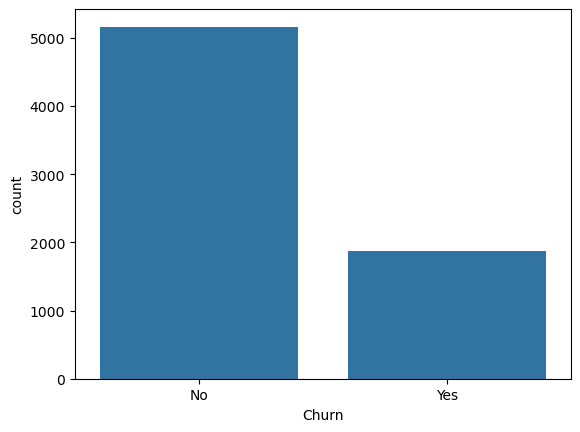

In [7]:
sns.countplot(data=df,x='Churn')

Text(0.5, 1.0, 'Tenure vs Churn')

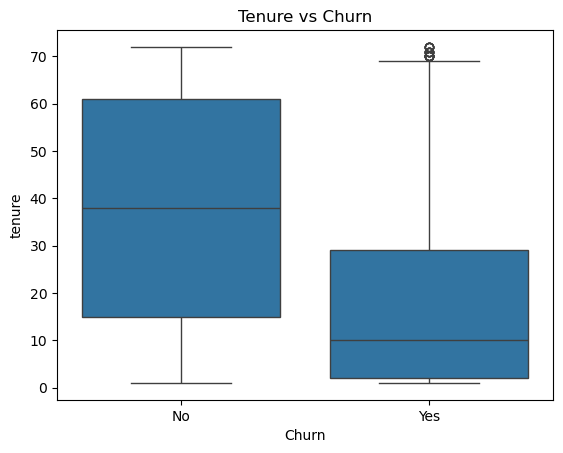

In [8]:
## Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")

Text(0.5, 1.0, 'Monthly Charges vs Churn')

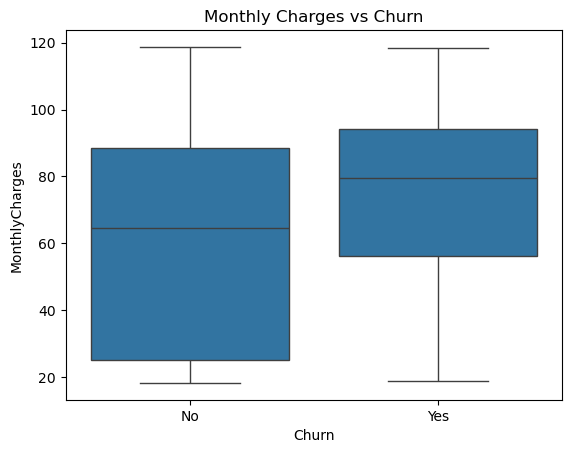

In [9]:
## Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")

In [10]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


## From EDA 
### 1. Tenure Insight
##### Low tenure → high churn
##### New customers leave more

### 2. Monthly Charges Insight
##### Higher monthly charges → more churn tendency

### 3. Contract Insight
##### Month-to-month → highest churn
##### Two-year → lowest churn


# Feature Engineering

In [11]:
def tenure_group(x):
    if x <= 12:
        return '0-12 Months'
    elif x <= 24:
        return '12-24 Months'
    elif x <= 48:
        return '24-48 Months'
    else:
        return 'Over 48 Months'

df['TenureGroup'] = df['tenure'].apply(tenure_group)

In [12]:
tenure_churn=pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index') * 100
tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 Months,52.321839,47.678161
12-24 Months,71.289062,28.710938
24-48 Months,79.611041,20.388959
Over 48 Months,90.486824,9.513176


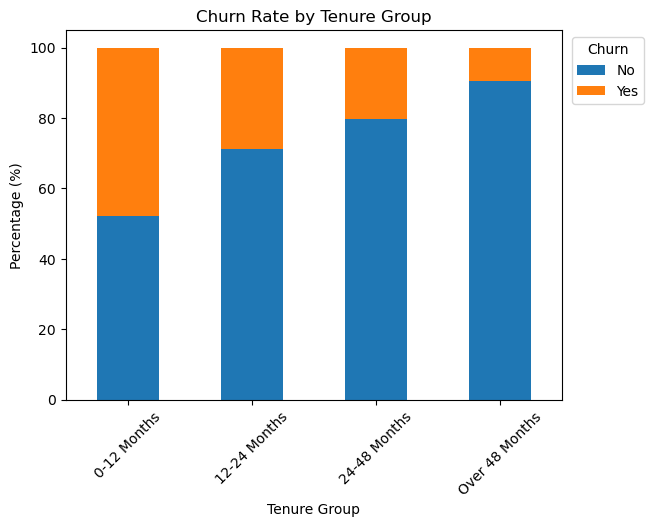

In [13]:
tenure_churn.plot(kind='bar', stacked=True)
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend(title="Churn",loc=(1.02,0.8))

# Advanced Feature Engineering

To improve model performance and better capture customer behavior, additional features are engineered.

These features represent customer engagement, spending behavior, and customer value.

The following new features are created:

• Customer Lifetime Value (CLV proxy)  
• Average Monthly Spending  
• Service Engagement Score  
• Total Services Subscribed  

These engineered features help the model better understand customer usage patterns and churn risk.

### Customer Lifetime Value (Proxy)

In [14]:
df['CLV'] = df['MonthlyCharges'] * df['tenure']
df[['tenure','MonthlyCharges','CLV']].head()

,tenure,MonthlyCharges,CLV
0,1,29.85,29.85
1,34,56.95,1936.30
2,2,53.85,107.70
3,45,42.30,1903.50
4,2,70.70,141.40


Customer Lifetime Value is approximated by multiplying monthly charges with tenure.

Higher CLV customers contribute more revenue to the company and are often prioritized for retention strategies.

### Average Monthly Spending

In [15]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
df[['tenure','MonthlyCharges','CLV','AvgMonthlySpend']].head()

,tenure,MonthlyCharges,CLV,AvgMonthlySpend
0,1,29.85,29.85,14.925000
1,34,56.95,1936.30,53.985714
2,2,53.85,107.70,36.050000
3,45,42.30,1903.50,40.016304
4,2,70.70,141.40,50.550000


Average monthly spending is calculated to understand the typical spending behavior of customers.

This helps identify high-value customers and analyze how spending relates to churn behavior.

### Service Engagement Score

In [16]:
services = [
'PhoneService',
'MultipleLines',
'OnlineSecurity',
'OnlineBackup',
'DeviceProtection',
'TechSupport',
'StreamingTV',
'StreamingMovies'
]
df['ServiceCount'] = df[services].apply(lambda x: (x=='Yes').sum(), axis=1)
df[['ServiceCount']].head()

,ServiceCount
0,1
1,3
2,3
3,3
4,1


Service engagement is measured by counting the number of telecom services subscribed by each customer.

Customers using more services tend to have stronger engagement with the company and lower churn probability.

### Service Engagement Insight

In [17]:
df['HasInternet'] = df['InternetService'].apply(lambda x: 0 if x == 'No' else 1)

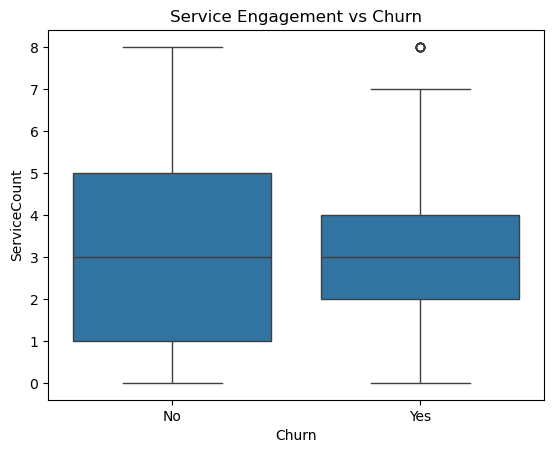

In [18]:
sns.boxplot(x='Churn', y='ServiceCount', data=df)
plt.title("Service Engagement vs Churn")
plt.show()

The Service Engagement Score represents the number of telecom services subscribed by each customer.

From the visualization, we observe that:

• Customers who churn generally subscribe to fewer services  
• Customers who stay tend to have slightly higher service engagement  
• Higher engagement may indicate stronger dependency on the telecom provider

This suggests that increasing service adoption (such as streaming services, tech support, or device protection) may help reduce churn risk.

In [19]:
df.groupby('Churn')['ServiceCount'].mean()

Churn
No     3.447027
Yes    3.132156
Name: ServiceCount, dtype: float64

The results show that retained customers subscribe to slightly more telecom services on average compared to churned customers.

This suggests that customers with higher service engagement may be more dependent on the telecom provider, which could reduce the likelihood of churn.

Encouraging customers to adopt additional services (such as streaming, security, or tech support) may help improve customer retention.

# Customer Segmentation using K-Means Clustering

Customer segmentation is performed to identify different groups of telecom customers based on their behavioral patterns.

Unlike churn prediction, which is a supervised learning problem, customer segmentation uses **unsupervised learning** to discover hidden patterns in the data without using the target variable.

Segmenting customers helps the business understand different customer profiles such as high-value customers, loyal customers, and potentially at-risk customers.

By analyzing these segments, companies can design targeted marketing strategies and retention campaigns for different types of customers.

In this project, we use **K-Means Clustering** to group customers based on key behavioral features:

• Tenure (how long the customer has stayed with the company)  
• Monthly Charges (customer spending behavior)  
• Customer Lifetime Value proxy (CLV)  
• Service Engagement Score (number of services subscribed)

These features capture important aspects of customer behavior, including engagement level, revenue contribution, and loyalty.

Before applying K-Means clustering, the selected features are **scaled using StandardScaler** to ensure that all variables contribute equally to the clustering process.

To determine the optimal number of clusters, we apply the **Elbow Method**, which evaluates how the clustering inertia decreases as the number of clusters increases.

After determining the optimal number of clusters, we assign each customer to a segment and analyze the characteristics of each cluster to understand different customer groups.

In [20]:
# Selecting features for segmentation
seg_features = df[['tenure','MonthlyCharges','CLV','ServiceCount']]
seg_features.head()

,tenure,MonthlyCharges,CLV,ServiceCount
0,1,29.85,29.85,1
1,34,56.95,1936.30,3
2,2,53.85,107.70,3
3,45,42.30,1903.50,3
4,2,70.70,141.40,1


In [21]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_features)

In [22]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(seg_scaled)
    inertia.append(kmeans.inertia_)

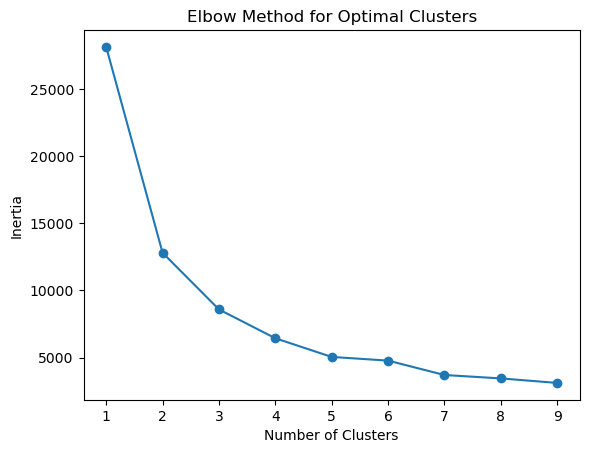

In [23]:
import matplotlib.pyplot as plt

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

In [24]:
# Applying KMeans with optimal clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df['CustomerSegment'] = kmeans.fit_predict(seg_scaled)
df['CustomerSegment'].value_counts()

CustomerSegment
3    2212
0    1935
1    1802
2    1083
Name: count, dtype: int64

In [25]:
df.groupby('CustomerSegment')[['tenure','MonthlyCharges','CLV','ServiceCount']].mean()

,tenure,MonthlyCharges,CLV,ServiceCount
CustomerSegment,,,,
0,59.398450,92.883850,5504.028553,5.798450
1,9.397891,34.997752,285.480966,1.289678
2,53.869806,32.998430,1754.328301,1.918744
3,17.078662,80.075723,1351.908657,3.629747


In [26]:
churn_segment = pd.crosstab(df['CustomerSegment'], df['Churn'], normalize='index').mul(100).round(2)
churn_segment.columns = ['No Churn (%)', 'Churn (%)']
churn_segment

,No Churn (%),Churn (%)
CustomerSegment,,
0,84.91,15.09
1,70.81,29.19
2,94.55,5.45
3,55.15,44.85


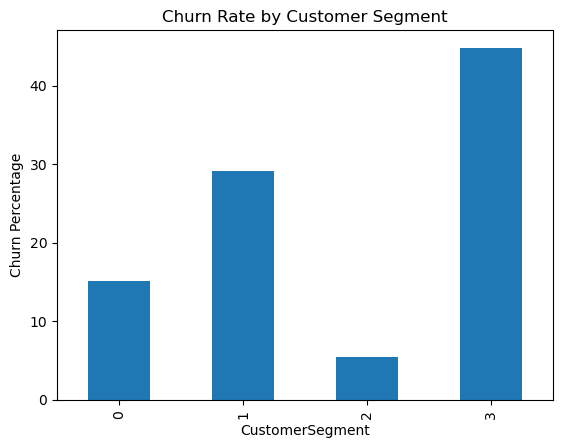

In [27]:
churn_segment['Churn (%)'].plot(kind='bar',title='Churn Rate by Customer Segment')
plt.ylabel('Churn Percentage')
plt.show()

### Customer Segment Analysis

Using K-Means clustering, customers were grouped into four segments based on their behavioral characteristics including tenure, spending, and service engagement.

The analysis of these clusters helps identify different types of customers such as loyal customers, high spending customers, and potentially at-risk customers.

By analyzing churn rates across segments, businesses can better understand which types of customers are more likely to leave and design targeted retention strategies accordingly.

### Customer Segment Interpretation

Based on the clustering results, four distinct customer segments were identified:

**Segment 0 – High Value Loyal Customers**
- Long tenure
- High monthly spending
- High service engagement
- Low churn rate (~15%)

These customers generate the highest revenue and show strong loyalty to the company.

**Segment 1 – New Low-Value Customers**
- Low tenure
- Low service usage
- Low spending
- Moderate churn rate (~29%)

These customers are relatively new and may require engagement strategies to improve retention.

**Segment 2 – Stable Low-Spending Customers**
- Long tenure
- Low monthly charges
- Low service engagement
- Very low churn rate (~5%)

These customers are stable but contribute lower revenue.

**Segment 3 – High Risk Customers**
- Medium tenure
- High monthly charges
- Moderate engagement
- Highest churn rate (~44%)

These customers represent the most critical segment for retention strategies, as they are at the highest risk of churn.

# Preparing Data for Modeling

In [28]:
df = df.drop('customerID', axis=1)

In [29]:
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

In [30]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [31]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,CLV,AvgMonthlySpend,ServiceCount,HasInternet,CustomerSegment,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_12-24 Months,TenureGroup_24-48 Months,TenureGroup_Over 48 Months
0,0,1,29.85,29.85,0,29.85,14.925000,1,1,1,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,0,1936.30,53.985714,3,1,3,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,1,107.70,36.050000,3,1,1,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,0,1903.50,40.016304,3,1,2,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,1,141.40,50.550000,1,1,1,...,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,84.80,1990.50,0,2035.20,79.620000,7,1,3,...,True,True,False,True,False,False,True,True,False,False
7028,0,72,103.20,7362.90,0,7430.40,100.861644,6,1,0,...,True,True,False,True,True,False,False,False,False,True
7029,0,11,29.60,346.45,0,325.60,28.870833,1,1,1,...,False,False,False,True,False,True,False,False,False,False
7030,1,4,74.40,306.60,1,297.60,61.320000,2,1,3,...,False,False,False,True,False,False,True,False,False,False


In [32]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'CLV',
       'AvgMonthlySpend', 'ServiceCount', 'HasInternet', 'CustomerSegment'],
      dtype='object')

# Define Features (X) and Target (y)

In [33]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Train-Test Split (With Stratification)

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Train Decision Tree

In [35]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

# Make Predictions

In [36]:
y_pred = dt.predict(X_test)

# Evaluate

In [37]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[1262  287]
 [ 293  268]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1549
           1       0.48      0.48      0.48       561

    accuracy                           0.73      2110
   macro avg       0.65      0.65      0.65      2110
weighted avg       0.72      0.73      0.72      2110



# Train Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [39]:
y_pred_rf = rf.predict(X_test)

In [40]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix:
[[1399  150]
 [ 294  267]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.64      0.48      0.55       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.78      0.79      0.78      2110



In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [42]:
best_rf = grid.best_estimator_
best_rf

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [43]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob)

np.float64(0.8177922850576936)

In [44]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.108188
4,CLV,0.106359
3,TotalCharges,0.104168
5,AvgMonthlySpend,0.100110
2,MonthlyCharges,0.098284
30,Contract_Two year,0.051948
15,InternetService_Fiber optic,0.036969
33,PaymentMethod_Electronic check,0.034464
6,ServiceCount,0.026650
29,Contract_One year,0.021920


In [45]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')*100

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [46]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index')*100

Churn,0,1
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


# Gradient Boosting

In [47]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [48]:
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.63      0.49      0.55       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.71      2110
weighted avg       0.78      0.79      0.78      2110

ROC-AUC: 0.8369058756785183


In [49]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.307179
15,InternetService_Fiber optic,0.183876
33,PaymentMethod_Electronic check,0.090193
30,Contract_Two year,0.065634
2,MonthlyCharges,0.053961
4,CLV,0.044084
29,Contract_One year,0.039065
5,AvgMonthlySpend,0.035932
7,HasInternet,0.035411
3,TotalCharges,0.028653


# Logistic Regression, SVM, KNN

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": best_rf,   # tuned RF
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Recall (Churn)": report["1"]["recall"],
        "Precision (Churn)": report["1"]["precision"],
        "F1 (Churn)": report["1"]["f1-score"],
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)
comparison_df.sort_values(by="ROC-AUC", ascending=False)

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

,Model,Accuracy,Recall (Churn),Precision (Churn),F1 (Churn),ROC-AUC
0,Logistic Regression,0.802370,0.525847,0.661435,0.585899,0.840028
5,Gradient Boosting,0.788626,0.490196,0.632184,0.552209,0.836906
4,Random Forest,0.774408,0.721925,0.558621,0.629860,0.834263
2,SVM,0.734123,0.000000,0.000000,0.000000,0.778739
1,KNN,0.760190,0.420677,0.565947,0.482618,0.728232
3,Decision Tree,0.725118,0.477718,0.482883,0.480287,0.646776


# Cross-Validation

In [81]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    print(name, "Mean ROC-AUC:", scores.mean())

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

Logistic Regression Mean ROC-AUC: 0.8475744309745339
KNN Mean ROC-AUC: 0.7350786381756956
SVM Mean ROC-AUC: 0.7910856440662095
Decision Tree Mean ROC-AUC: 0.6559778332126733
Random Forest Mean ROC-AUC: 0.8436158169106476
Gradient Boosting Mean ROC-AUC: 0.844684625533963


# 📊 Final Model Comparison (ROC-AUC)

To visually compare model performance, we plot the cross-validated ROC-AUC scores of the top performing models.  
This helps identify which model generalizes best across different data splits.

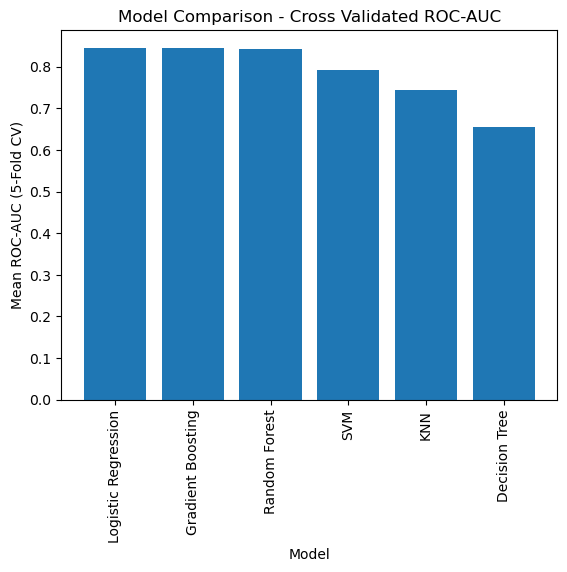

In [52]:
models_names = ["Logistic Regression", "Gradient Boosting", "Random Forest","SVM", "KNN","Decision Tree"]
roc_scores = [0.8458, 0.8454, 0.8435,0.7916,0.7435,0.6539]

plt.figure()
plt.bar(models_names, roc_scores)

plt.xlabel("Model")
plt.ylabel("Mean ROC-AUC (5-Fold CV)")
plt.title("Model Comparison - Cross Validated ROC-AUC")
plt.xticks(rotation=90)

plt.show()

# Selecting the Best Model
Based on the model comparison results, Logistic Regression achieved the highest ROC-AUC score and demonstrated stable performance across cross-validation. Therefore, Logistic Regression is selected as the final model for further evaluation and interpretation.

# ROC Curve Analysis
The ROC (Receiver Operating Characteristic) curve visualizes the performance of the classification model by plotting the True Positive Rate against the False Positive Rate at different classification thresholds.
A curve closer to the top-left corner indicates better model performance.

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


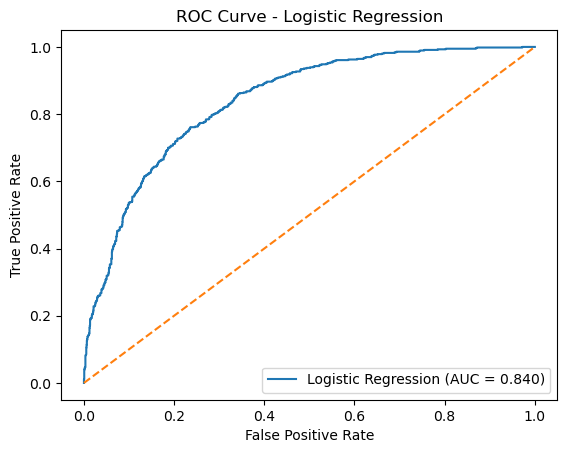

In [82]:
# Final model selection
final_model = LogisticRegression(max_iter=2000) 

# Train the model
final_model.fit(X_train, y_train)

from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class
y_prob = final_model.predict_proba(X_test)[:, 1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)
log_model = final_model

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.show()

In [83]:
scores = cross_val_score(log_model, X, y, cv=5, scoring='roc_auc')
print("Mean:", scores.mean())
print("Std Dev:", scores.std())

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

Mean: 0.8475744309745339
Std Dev: 0.010803619188978767


D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [85]:
from sklearn.metrics import classification_report
print(classification_report(y_test, final_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.66      0.53      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.71      0.73      2110
weighted avg       0.79      0.80      0.79      2110



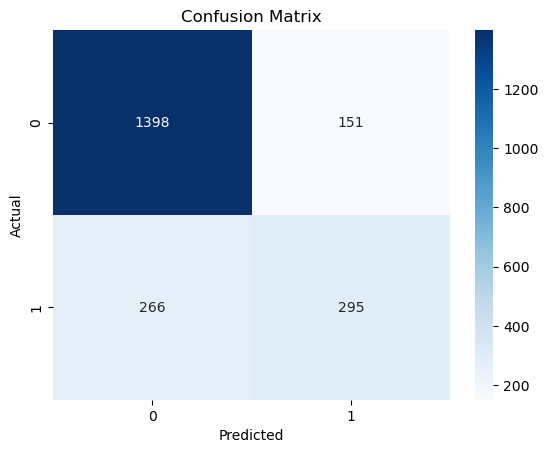

In [99]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, final_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Classification Report – Logistic Regression

To further evaluate the performance of the logistic regression model, a classification report is generated.  

This report summarizes key evaluation metrics including:

- Precision
- Recall
- F1-score
- Support

Recall is particularly important in churn prediction because failing to identify customers who will churn can result in significant revenue loss.

Therefore, a model with strong recall for the churn class is desirable.

# Extract Coefficients

In [86]:
log_model = models["Logistic Regression"]

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coeff_df = coeff_df.sort_values(by="Coefficient", ascending=False)

In [87]:
coeff_df["Odds_Ratio"] = coeff_df["Coefficient"].apply(lambda x: np.exp(x))
coeff_df.head(10)

,Feature,Coefficient,Odds_Ratio
15,InternetService_Fiber optic,0.646021,1.907934
14,MultipleLines_Yes,0.503670,1.654783
31,PaperlessBilling_Yes,0.327884,1.388028
33,PaymentMethod_Electronic check,0.313459,1.368149
26,StreamingTV_Yes,0.301822,1.352321
28,StreamingMovies_Yes,0.286182,1.331335
13,MultipleLines_No phone service,0.212993,1.237376
37,TenureGroup_Over 48 Months,0.173738,1.189743
0,SeniorCitizen,0.164296,1.178563
22,DeviceProtection_Yes,0.103643,1.109205


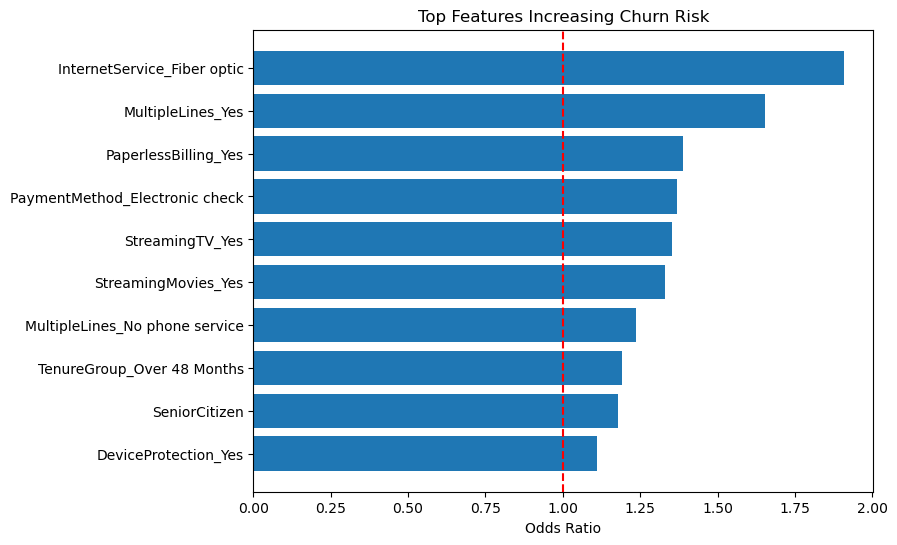

In [88]:
import matplotlib.pyplot as plt
top_features = coeff_df.head(10)
plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Odds_Ratio"])
plt.xlabel("Odds Ratio")
plt.title("Top Features Increasing Churn Risk")
plt.gca().invert_yaxis()
plt.axvline(x=1, color='red', linestyle='--')
plt.show()

In [89]:
coeff_df.tail(10)

,Feature,Coefficient,Odds_Ratio
19,OnlineBackup_No internet service,-0.107637,0.897954
36,TenureGroup_24-48 Months,-0.133493,0.875034
35,TenureGroup_12-24 Months,-0.197699,0.820617
7,HasInternet,-0.243676,0.783741
11,Dependents_Yes,-0.260437,0.770715
24,TechSupport_Yes,-0.303651,0.738118
18,OnlineSecurity_Yes,-0.310521,0.733065
12,PhoneService_Yes,-0.564306,0.568755
29,Contract_One year,-0.770957,0.462570
30,Contract_Two year,-1.542241,0.213901


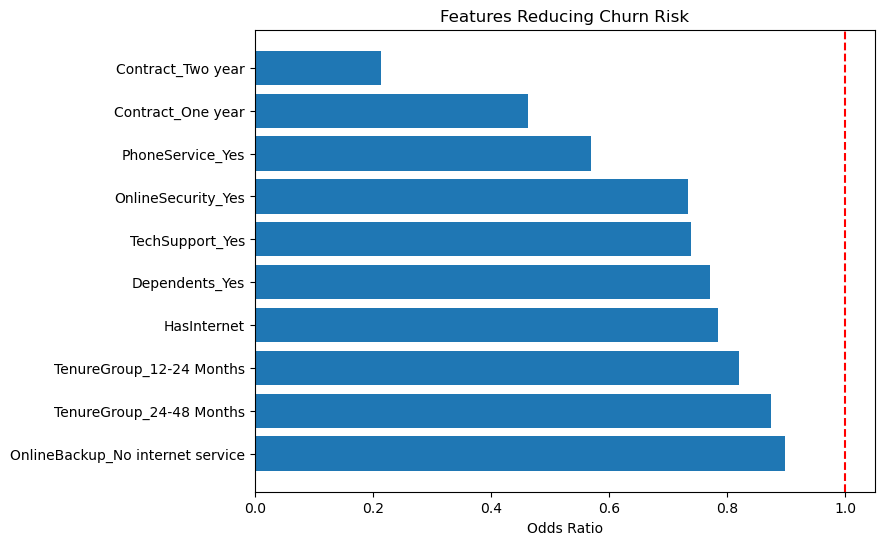

In [90]:
bottom_features = coeff_df.tail(10)
plt.figure(figsize=(8,6))
plt.barh(bottom_features["Feature"], bottom_features["Odds_Ratio"])
plt.xlabel("Odds Ratio")
plt.title("Features Reducing Churn Risk")
plt.axvline(x=1, color='red', linestyle='--')
plt.show()

### Logistic Regression Interpretation – Odds Ratio Analysis

To interpret the impact of each feature on churn probability, the logistic regression coefficients were converted into **odds ratios**.

An odds ratio greater than 1 indicates that the feature increases churn likelihood, while an odds ratio less than 1 indicates a protective factor against churn.

---

### Key Churn Drivers

The model identified several features associated with increased churn risk:

- **Fiber optic internet service** – customers using fiber optic internet show significantly higher churn likelihood.
- **Multiple phone lines** – customers with multiple lines appear more likely to switch providers.
- **Paperless billing** – customers using paperless billing show moderately higher churn risk.
- **Electronic check payment method** – this payment method is strongly associated with churn behavior.
- **Streaming services** – customers using streaming TV or movie services tend to churn slightly more.

These patterns may indicate higher expectations among premium service users or dissatisfaction with service quality.

---

### Protective Factors Against Churn

Several features were found to significantly reduce churn probability:

- **Two-year contracts** – customers with long-term contracts are much less likely to churn.
- **One-year contracts** – also associated with reduced churn compared to month-to-month plans.
- **Technical support services** – customers with tech support show stronger retention.
- **Online security services** – value-added services appear to increase customer loyalty.
- **Customers with dependents** – these customers tend to remain longer with the provider.

These findings suggest that **long-term contracts and value-added services play a key role in customer retention strategies.**

# Understanding Why Customers Churn

## 📊 Customer Churn Drivers – Visual Dashboard Summary
This section presents a visual summary of the key factors contributing to customer churn.  
The objective is to clearly demonstrate churn patterns for non-technical stakeholders.

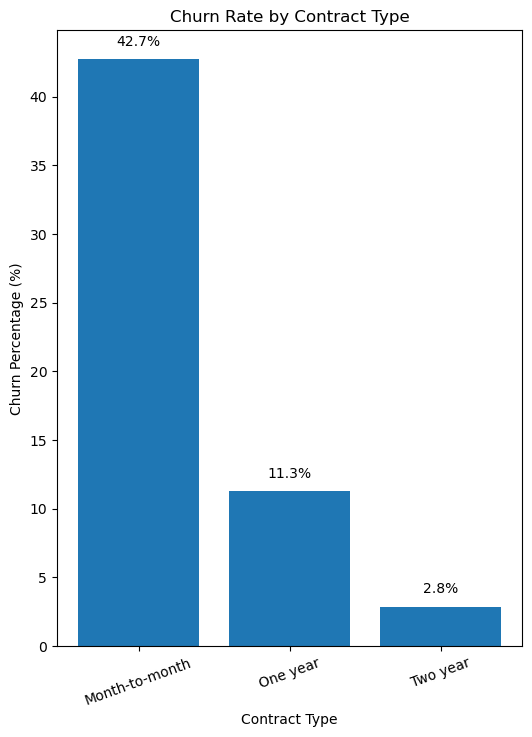

In [91]:
# Churn Rate by Contract Type
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

plt.figure(figsize=(6,8))
plt.bar(contract_churn.index, contract_churn[1])

for i, v in enumerate(contract_churn[1]):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.xlabel("Contract Type")
plt.ylabel("Churn Percentage (%)")
plt.title("Churn Rate by Contract Type")

plt.xticks(rotation=20)
plt.show()

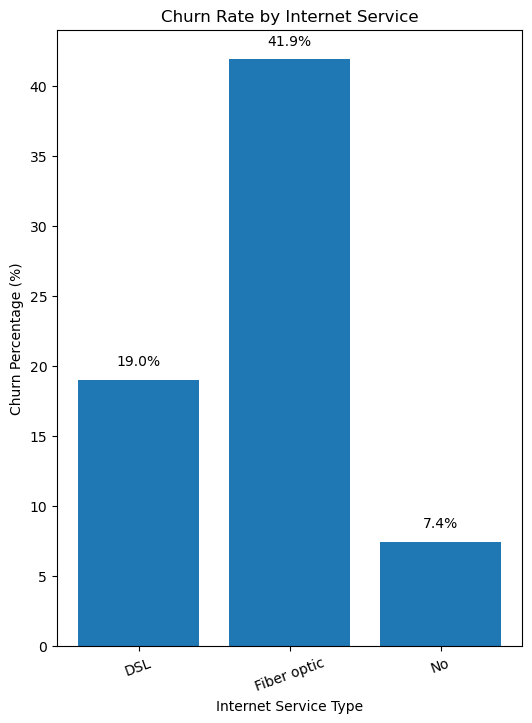

In [92]:
# Churn Rate by Internet Service 
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

plt.figure(figsize=(6,8))
plt.bar(internet_churn.index, internet_churn[1])

for i, v in enumerate(internet_churn[1]):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.xlabel("Internet Service Type")
plt.ylabel("Churn Percentage (%)")
plt.title("Churn Rate by Internet Service")

plt.xticks(rotation=20)
plt.show()

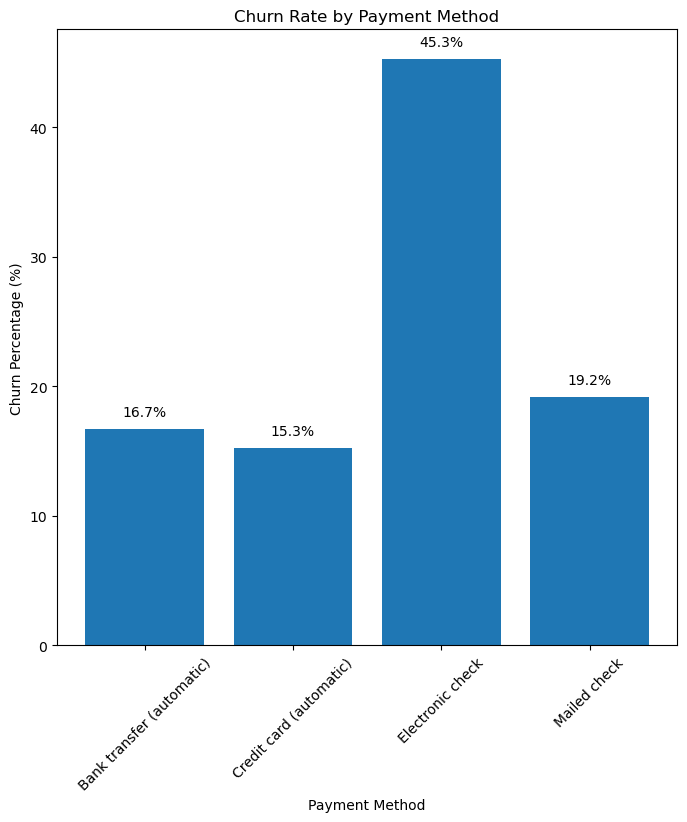

In [93]:
# Churn Rate by Payment Method
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

plt.figure(figsize=(8,8))
plt.bar(payment_churn.index, payment_churn[1])

for i, v in enumerate(payment_churn[1]):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.xlabel("Payment Method")
plt.ylabel("Churn Percentage (%)")
plt.title("Churn Rate by Payment Method")

plt.xticks(rotation=45)
plt.show()

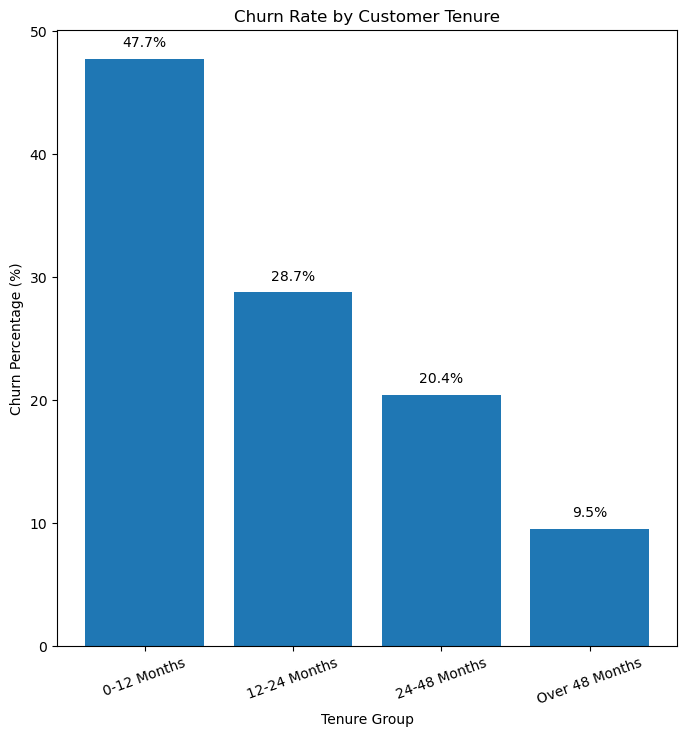

In [94]:
# Churn Rate by Tenure Group
tenure_churn = pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index') * 100

plt.figure(figsize=(8,8))
plt.bar(tenure_churn.index, tenure_churn[1])

for i, v in enumerate(tenure_churn[1]):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.xlabel("Tenure Group")
plt.ylabel("Churn Percentage (%)")
plt.title("Churn Rate by Customer Tenure")

plt.xticks(rotation=20)
plt.show()

## Customer Churn Drivers – Visual Analysis

To complement the predictive modeling results, a visual analysis was conducted to identify key factors associated with customer churn.

The following plots illustrate churn patterns across different customer attributes including payment method, contract type, internet service, and customer tenure.

### Key Observations

• **Month-to-month contracts show the highest churn rates**, indicating that customers without long-term commitments are more likely to switch providers.

• **Fiber optic internet users exhibit significantly higher churn compared to DSL users**, potentially due to higher service expectations or pricing sensitivity.

• **Electronic check payment method is strongly associated with churn**, suggesting that customers using manual payment methods may be less engaged.

• **Early lifecycle customers (0–12 months) show the highest churn rates**, highlighting the importance of onboarding and early customer engagement.

Overall, these patterns align closely with the machine learning model interpretation and the risk segmentation analysis.

# Risk Segmentation
### “Which customers are high risk and should be targeted first?”

In [95]:
# Get churn probabilities
log_model = models["Logistic Regression"]

probs = log_model.predict_proba(X_test)[:,1]

risk_df = pd.DataFrame({
    "Actual_Churn": y_test,
    "Predicted_Probability": probs
})

risk_df.head()

,Actual_Churn,Predicted_Probability
4214,0,0.195276
1815,0,0.248549
2370,0,0.056266
5453,0,0.055065
1786,0,0.034425


In [96]:
risk_df["Risk_Level"] = pd.cut(
    risk_df["Predicted_Probability"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_df["Risk_Level"].value_counts()

Risk_Level
Low Risk       1312
Medium Risk     506
High Risk       292
Name: count, dtype: int64

In [97]:
pd.crosstab(risk_df["Risk_Level"], risk_df["Actual_Churn"], normalize='index') * 100

Actual_Churn,0,1
Risk_Level,,
Low Risk,89.786585,10.213415
Medium Risk,54.743083,45.256917
High Risk,32.191781,67.808219


In [98]:
risk_df.sort_values(by="Predicted_Probability", ascending=False).head(20)

,Actual_Churn,Predicted_Probability,Risk_Level
3374,1,0.955810,High Risk
4577,1,0.929632,High Risk
6231,1,0.927688,High Risk
6359,1,0.922653,High Risk
5774,1,0.922277,High Risk
2241,1,0.919083,High Risk
5465,0,0.918518,High Risk
641,1,0.910005,High Risk
2392,1,0.907795,High Risk
2748,1,0.907365,High Risk


# 📌 Executive Summary

After evaluating six supervised learning models, Logistic Regression achieved the highest cross-validated ROC-AUC (0.8458 ± 0.0107), demonstrating strong and stable performance.

Key churn drivers include:
- Fiber optic service
- Electronic check payment method
- Month-to-month contracts

Protective factors:
- Two-year contracts
- Tech support
- Online security

Risk segmentation identified 14% of customers as high-risk, among whom 69% actually churned, enabling targeted retention strategies.

## Conclusion

This project demonstrates how machine learning can be used to predict customer churn and identify high-risk customers.

Key contributions include:

• Behavioral feature engineering  
• Customer segmentation using K-Means  
• Logistic regression churn prediction model  
• Risk-based customer targeting system  
• Business insights for churn prevention

The system can be extended into a production environment through deployment as a web application and API.

## Model Monitoring & Retraining Strategy

In a real production environment, customer behavior changes over time due to market conditions, pricing strategies, and service offerings. These changes may lead to **model drift**, where the model's predictive performance gradually degrades.

To maintain reliable predictions, the following monitoring strategy can be applied:

### Performance Monitoring
The model's performance should be tracked periodically using metrics such as:

- ROC-AUC
- Precision and Recall for churn class
- Overall prediction accuracy

If the performance drops below an acceptable threshold, retraining should be triggered.

### Data Drift Monitoring
Key input features such as:

- Monthly charges
- Tenure
- Service usage
- Payment methods

should be monitored for distribution shifts compared to the training dataset.

Techniques such as **Population Stability Index (PSI)** or **distribution comparison plots** can be used to detect drift.

### Retraining Strategy
The model should be retrained periodically using newly collected customer data. A recommended approach is:

- Retrain every 3–6 months
- Incorporate new behavioral features
- Re-evaluate model performance
- Redeploy the updated model

This ensures the churn prediction system remains accurate and aligned with evolving customer behavior.

In [15]:
import joblib

model = joblib.load("../models/churn_model.pkl")
features = joblib.load("../models/model_features.pkl")

In [16]:
import os
os.listdir("../models")

['churn_model.pkl', 'model_features.pkl']